# データサイエンス特論 第12回 事前課題
青山学院大学大学院 理工学研究科 理工学専攻 知能情報コース 修士1年 35626302 森下剛

In [68]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import cross_val_score

### 重回帰における正則化

In [69]:
# 糖尿病データセットの読み込み
diabetes_data = load_diabetes()

diabetes_df = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
diabetes_df["target"] = diabetes_data.target

X = diabetes_df[diabetes_data.feature_names]
y = diabetes_df["target"]

#### 事前課題1の解答

In [70]:
def lasso(X, y, alpha):
    # Lasso 回帰モデル
    lasso = Lasso(alpha)

    # 5分割交差検証
    mae_scores = -cross_val_score(lasso, X, y, cv=5, scoring="neg_mean_absolute_error") # MAE
    rmse_scores = -cross_val_score(lasso, X, y, cv=5, scoring="neg_root_mean_squared_error") # RMSE

    for i, (mae, rmse) in enumerate(zip(mae_scores, rmse_scores), start=1):
        print(f"Fold {i}: MAE = {mae}, RMSE = {rmse}")

    mae_mean = mae_scores.mean()
    rmse_mean = rmse_scores.mean()
    print(f"\nMean of MAE : {mae_mean}")
    print(f"Mean of RMSE: {rmse_mean}")

    return mae_mean, rmse_mean

In [71]:
lasso(X, y, alpha=1.0)

Fold 1: MAE = 50.09006473243525, RMSE = 59.0909645014831
Fold 2: MAE = 52.54118496139127, RMSE = 64.13938337509052
Fold 3: MAE = 55.02819607484326, RMSE = 63.6153389591182
Fold 4: MAE = 50.811289300738615, RMSE = 59.07412096630651
Fold 5: MAE = 55.60479053459792, RMSE = 64.12430694384787

Mean of MAE : 52.81510512080126
Mean of RMSE: 62.008822949169236


(np.float64(52.81510512080126), np.float64(62.008822949169236))

===== alpha = 0.001 =====
Fold 1: MAE = 43.05094406990564, RMSE = 52.752788803890404
Fold 2: MAE = 44.8158470828729, RMSE = 55.0454846515074
Fold 3: MAE = 48.10109899858164, RMSE = 56.85030979925282
Fold 4: MAE = 42.985602675651826, RMSE = 54.82544897838524
Fold 5: MAE = 42.38586634389271, RMSE = 53.990734717413176

Mean of MAE : 44.267871834180944
Mean of RMSE: 54.69295339008981

===== alpha = 0.01 =====
Fold 1: MAE = 43.28036313846982, RMSE = 52.9104009448539
Fold 2: MAE = 44.933299727649896, RMSE = 55.14588478027558
Fold 3: MAE = 47.85896822200957, RMSE = 56.561777461135215
Fold 4: MAE = 42.8917354795461, RMSE = 54.89661901873603
Fold 5: MAE = 42.60487844754059, RMSE = 54.26729747880246

Mean of MAE : 44.313849003043195
Mean of RMSE: 54.75639593676063

===== alpha = 0.1 =====
Fold 1: MAE = 44.049603663936786, RMSE = 53.979041695454725
Fold 2: MAE = 45.72929230735683, RMSE = 55.46627501993891
Fold 3: MAE = 48.214122920899875, RMSE = 56.56248773555995
Fold 4: MAE = 42.22760987909501, 

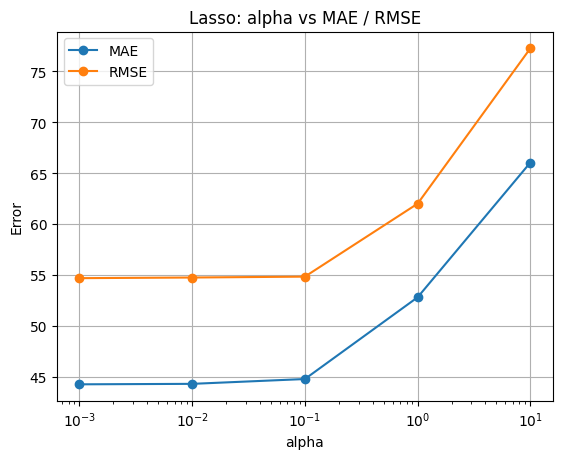

In [72]:
# alpha を変化させて MAE と RMSE の変化を観察する
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]

mae_list = []
rmse_list = []

for alpha in alphas:
    print(f"===== alpha = {alpha} =====")
    mae_mean, rmse_mean = lasso(X, y, alpha)
    mae_list.append(mae_mean)
    rmse_list.append(rmse_mean)
    print()

# alpha と誤差の関係をグラフ化
plt.plot(alphas, mae_list, marker="o", label="MAE")
plt.plot(alphas, rmse_list, marker="o", label="RMSE")

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Error")
plt.title("Lasso: alpha vs MAE / RMSE")
plt.legend()
plt.grid(True)
plt.show()

#### 事前課題2の解答

In [73]:
def ridge(X, y, alpha):
    # Ridge 回帰モデル
    ridge = Ridge(alpha)

    # 5分割交差検証
    mae_scores = -cross_val_score(ridge, X, y, cv=5, scoring="neg_mean_absolute_error") # MAE
    rmse_scores = -cross_val_score(ridge, X, y, cv=5, scoring="neg_root_mean_squared_error") # RMSE

    for i, (mae, rmse) in enumerate(zip(mae_scores, rmse_scores), start=1):
        print(f"Fold {i}: MAE = {mae}, RMSE = {rmse}")

    mae_mean = mae_scores.mean()
    rmse_mean = rmse_scores.mean()
    print(f"\nMean of MAE : {mae_mean}")
    print(f"Mean of RMSE: {rmse_mean}")

    return mae_mean, rmse_mean

In [74]:
ridge(X, y, alpha=1.0)

Fold 1: MAE = 47.34448291545924, RMSE = 57.49528193080485
Fold 2: MAE = 47.69836674876847, RMSE = 59.58026817243209
Fold 3: MAE = 52.80031860497601, RMSE = 60.139952561818596
Fold 4: MAE = 45.956364743744125, RMSE = 54.939795180463726
Fold 5: MAE = 50.89511081645127, RMSE = 60.09084442480773

Mean of MAE : 48.93892876587982
Mean of RMSE: 58.449228454065405


(np.float64(48.93892876587982), np.float64(58.449228454065405))

===== alpha = 0.001 =====
Fold 1: MAE = 43.06506956174912, RMSE = 52.75837797451299
Fold 2: MAE = 44.828107270883855, RMSE = 55.060965351338986
Fold 3: MAE = 48.06650886939071, RMSE = 56.81610872047902
Fold 4: MAE = 42.983973941128184, RMSE = 54.83133563831474
Fold 5: MAE = 42.38895305787553, RMSE = 53.996563254781336

Mean of MAE : 44.266522540205486
Mean of RMSE: 54.69267018788541

===== alpha = 0.01 =====
Fold 1: MAE = 43.292786822200156, RMSE = 52.95339075295108
Fold 2: MAE = 44.94743036080425, RMSE = 55.18160832698144
Fold 3: MAE = 47.82535967035483, RMSE = 56.541499778067276
Fold 4: MAE = 42.84643921133115, RMSE = 54.78828038848883
Fold 5: MAE = 42.559349034602924, RMSE = 54.22813285695044

Mean of MAE : 44.294273019858664
Mean of RMSE: 54.73858242068782

===== alpha = 0.1 =====
Fold 1: MAE = 43.982146724706546, RMSE = 53.563301517306265
Fold 2: MAE = 45.038735298019404, RMSE = 55.27203405576566
Fold 3: MAE = 48.11977160517784, RMSE = 56.3751903394076
Fold 4: MAE = 42.68088004700

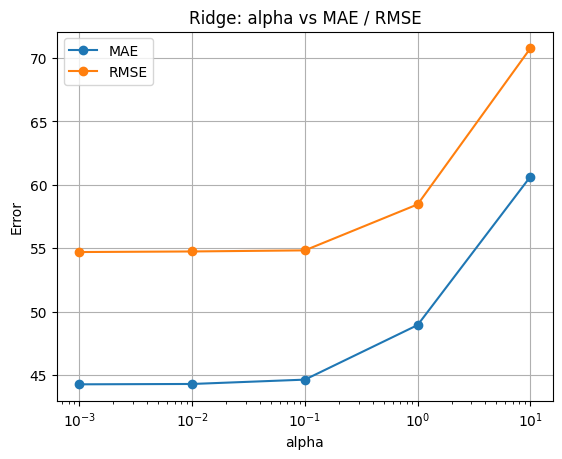

In [75]:
# alpha を変化させて MAE と RMSE の変化を観察する
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]

mae_list = []
rmse_list = []

for alpha in alphas:
    print(f"===== alpha = {alpha} =====")
    mae_mean, rmse_mean = ridge(X, y, alpha)
    mae_list.append(mae_mean)
    rmse_list.append(rmse_mean)
    print()

# alpha と誤差の関係をグラフ化
plt.plot(alphas, mae_list, marker="o", label="MAE")
plt.plot(alphas, rmse_list, marker="o", label="RMSE")

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Error")
plt.title("Ridge: alpha vs MAE / RMSE")
plt.legend()
plt.grid(True)
plt.show()

alphaが大きくなるとRidge回帰モデルの方が精度が高くなる。Lasso回帰モデルはハイパラの影響を受けやすいのではないか。

### ハイパーパラメータの探索

#### 事前課題3の解答

**GridSearchCV の調査**
- ハイパラの候補をあらかじめ複数指定しておき、その全組み合わせを交差検証で評価して、最も性能の良い組み合わせを自動で探し出す手法である。
- 評価したいモデルと、ハイパラの候補をまとめた辞書を渡して GridSearchCV のインスタンスを作り、fit() にデータを渡すと、全組み合わせの交差検証が実行され、最良の組み合わせで学習し直したモデルが得られる。
- best_params_ で最も性能の良かったハイパラの組み合わせを、best_score_ でそのときの交差検証スコアを確認できる。また best_estimator_ で最良のパラメータで学習済みのモデルを取り出せる。

引数は以下の通りである。
- estimator：探索の対象となるモデルを指定する。
- param_grid：探索したいハイパラ名をキー、その候補値のリストを値とした辞書を指定する。
- scoring：組み合わせの良し悪しを判断する評価指標を指定する。
- cv：交差検証の分割数を指定する。
- n_jobs：計算に使う CPU のコア数を指定する。
